# Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [19]:
#importing custom library
!pip install git+https://github.com/Vrboska/mofr@master

  Cloning https://github.com/Vrboska/mofr (to revision master) to c:\users\hp\appdata\local\temp\pip-req-build-3m2jrll3
  Resolved https://github.com/Vrboska/mofr to commit 9e35370debae10d418189ddd58b213a64b210895
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for mofr: filename=mofr-1.0-py3-none-any.whl size=25963 sha256=06991231b8b859295ff75fd4e936d1e00f0f59b4b4fd7862168150955cc17b24
  Stored in directory: C:\Users\hp\AppData\Local\Temp\pip-ephem-wheel-cache-z48hyncz\wheels\a2\43\f9\72709aa2a4439e0280f16fbd6e69f006d1aebdb0ee4f3d21bc
Successfully built mofr


  Running command git clone --filter=blob:none --quiet https://github.com/Vrboska/mofr 'C:\Users\hp\AppData\Local\Temp\pip-req-build-3m2jrll3'
  Running command git checkout -b master --track origin/master
  Branch 'master' set up to track remote branch 'master' from 'origin'.
  Switched to a new branch 'master'


In [20]:
import mofr

In [2]:
df_data = pickle.load(open(r"Z:\Algo_data\ob_trd_secmkts_oct-mar24.pkl", 'rb'))

# XGB model

## Data prep

Filter data entries when trade occurs for the purpose of margin feature

In [3]:
l_margin_calc = lambda row: row['trd_price'] - row['a_price'] if row['trd_side'] > 0.5 else row['b_price'] - row['trd_price']
l_traded_filter = lambda row: bool(row['trd_price'] > 0)

In [4]:
data_set = df_data[df_data.apply(l_traded_filter, axis=1)]
# drop entries where bid or ask price is not defined
data_set.dropna(subset=['b_price', 'a_price'], inplace=True)
# add feature margin
data_set['margin'] = data_set.apply(l_margin_calc, axis=1)

C:\Users\hp\AppData\Local\Temp\ipykernel_20156\11877204.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set.dropna(subset=['b_price', 'a_price'], inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_20156\11877204.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['margin'] = data_set.apply(l_margin_calc, axis=1)


There is originaly label defined as [-1, 0, 1]

We want labels [0, 1] for each model (long, short)

In [5]:
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0
l_neu_relabel = lambda x: 1 if x < 0.5 and x > -0.5 else 0

Method for spliting dataset into train and test sets

**Arguments**:
- l_func : function for relabeling
- train : int<0,100> percent in train set (test set contains [n:] entries)
- **margin_ratio** : is used for balancing dataset on margin values. Margin is negative in most cases we want to have balanced values in training set because we assume that this should be strongest predictor. Value represents portion of data with margin greater than 0.03eur to data without margin (e.g. margin_ratio = 0.3 -> margin_data = 200, no_margin_data = cca 600)

In [6]:
def dataset_split(df, l_func=None, train: int = 50, margin_ratio=0.2, balance=False):
    idx = int(np.percentile(df.index, train))
    train = df[df.index < idx].copy()
    test = df[df.index > idx].copy()
    if l_func:
        train['y'] = train['y'].apply(l_func)
        test['y'] = test['y'].apply(l_func)

    def balance_split(data, margin_ratio):
        margin_data = data[(data['margin'] > .03) & (data['margin'] < .3)]
        wo_margin_data = data[(data['margin'] < .03)]
        return pd.concat([margin_data, wo_margin_data.sample(
            frac=min(0.99, margin_data.shape[0]/margin_ratio/wo_margin_data.shape[0]))]).sample(frac=.8).set_index('timestamp').reset_index()
    
    def balance_on_y(data):
        positives = sum(data['y'] == 1)
        idxs = data[data['y'] == 0].sample(positives).index
        return data[(data.index.isin(idxs)) | (data['y'] == 1)]
    
    if balance:   
        return balance_on_y(balance_split(train, margin_ratio)), test
    else:
        return train, test

In [7]:
# 0.2 for margin_ratio is used for this experiment, can be increased but this will reduce samples in data sets
train, test = dataset_split(data_set)
train['y'].value_counts()

y
 0.0    18720
-1.0    13471
 1.0    13383
Name: count, dtype: int64

In [8]:
train.describe()

,timestamp,ba_spread,b_price,a_price,mid_price,ba_volrat_0.5,mid_priceW_0.5,b_price_sparsity,a_price_sparsity,p_movement,y,trd_price,trd_vol,trd_side,last_trd_p,diff_de_q,diff_de_y,diff_ttf_m,margin
count,46216,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,4.621600e+04,45574.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000,46216.000000
mean,2023-12-13 02:23:43.427254784,0.001828,90.090387,90.255674,90.173031,-0.013293,0.000730,0.285310,0.265537,2.990719e-02,-0.001931,90.180364,1.558768,0.562424,90.180364,-0.000188,-0.000068,0.000048,-0.019752
min,2023-11-01 09:00:09,0.000000,67.000000,67.000000,67.000000,-0.923077,-0.260000,0.000000,0.000000,-1.000000e+00,-1.000000,67.000000,1.000000,0.000000,67.000000,-0.128696,-0.034215,-0.059617,-0.490000
25%,2023-11-21 11:48:06,0.000945,84.110000,84.250000,84.195000,-0.333333,-0.015000,0.170000,0.160000,-3.117361e-01,-1.000000,84.200000,1.000000,0.000000,84.200000,-0.001349,-0.001283,-0.001664,-0.040000
50%,2023-12-12 13:40:24.500000,0.001611,93.505000,93.690000,93.600000,0.000000,0.000000,0.240000,0.230000,-1.438884e-27,0.000000,93.600000,1.000000,1.000000,93.600000,-0.000033,0.000018,0.000049,0.000000
75%,2024-01-05 13:27:28.500000,0.002470,96.790000,96.990000,96.880000,0.333333,0.016667,0.370000,0.340000,3.500694e-01,1.000000,96.900000,2.000000,1.000000,96.900000,0.001192,0.001280,0.001787,0.000000
max,2024-01-24 11:06:45,0.014099,106.610000,106.800000,106.700000,0.931034,0.323182,1.000000,1.000000,1.000000e+00,1.000000,106.700000,50.000000,1.000000,106.700000,0.050838,0.037745,0.042972,2.930000
std,NaN,0.001252,9.063365,9.083972,9.073487,0.361476,0.034847,0.164363,0.147085,5.238423e-01,0.767625,9.073460,1.454391,0.496093,9.073460,0.003290,0.002981,0.004166,0.062019


**Predictor description**

- `margin`: represents gap between traded price and best order price
- `p_movement`: is accumualating operator for mid price (t0-t1), contains value between <-1.0, 1.0>, 1.0 basically means that price is in local maximum, -1.0 the opposite.
- `b_price_sparsity, a_price_sparsity`: value between <0.0, 1.0>
- `ba_volrat_0.5`: volume ratio between bid and ask <-1.0, 1.0>
- `mid_priceW_0.5`: weighted mid price, value that is centered around 0.0, when there is more volume on bid value increases
- `diff_`: differentiated mid returns for secondary markets

In [13]:
train['y']=train['y'].apply(l_long_relabel)
test['y']=test['y'].apply(l_long_relabel)

### Univariate predictor power

In [21]:
feature_cols = [
    'margin',
    'p_movement',
    'b_price_sparsity',
    'a_price_sparsity', 
    'ba_volrat_0.5', 
    'mid_priceW_0.5',
    'diff_de_q',
    'diff_de_y',
    'diff_ttf_m'
]

In [23]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(test['y'], test[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,margin,0.070365
1,p_movement,0.108299
2,b_price_sparsity,-0.009924
3,a_price_sparsity,0.076166
4,ba_volrat_0.5,0.019950
5,mid_priceW_0.5,-0.028987
6,diff_de_q,0.097858
7,diff_de_y,0.097885
8,diff_ttf_m,0.074698


# Model Fitting

In [89]:
xgb_model = XGBClassifier(max_depth=4, gamma=1, min_child_weight=5, n_estimators=10)
xgb_model.fit(train[feature_cols],
              train['y'], eval_metric='logloss')
preds_ = xgb_model.predict_proba(test[feature_cols])
train['XGB_SCORE']=xgb_model.predict_proba(train[feature_cols])[:, 1]
test['XGB_SCORE']=xgb_model.predict_proba(test[feature_cols])[:, 1]


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


In [90]:
print('The Lift on the train set is: '+ str(mofr.metrics.lift(train['y'], train['XGB_SCORE'])))
print('The gini on the train set is: '+ str(mofr.metrics.gini(train['y'].apply(int), train['XGB_SCORE'])))
print('The accuracy on the train set is: '+ str(mofr.metrics.accuracy_score(train['y'].apply(int), train['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')
print('The Lift on the test set is: '+ str(mofr.metrics.lift(test['y'], test['XGB_SCORE'])))
print('The gini on the test set is: '+ str(mofr.metrics.gini(test['y'].apply(int), test['XGB_SCORE'])))
print('The accuracy on the test set is: '+ str(mofr.metrics.accuracy_score(test['y'].apply(int), test['XGB_SCORE'].apply(lambda x: int(x>0.5)))))
print('\n')

The Lift on the train set is: 1.8470116996008048
The gini on the train set is: 0.31942398235442715
The accuracy on the train set is: 0.7127401765622295


The Lift on the test set is: 1.3241762171059297
The gini on the test set is: 0.16186143673851117
The accuracy on the test set is: 0.6387181928336507




In [88]:
from mofr.basic_evaluators.ROCCurve import ROCCurveEvaluator
train['one']=1
test['one']=1


rce=ROCCurveEvaluator()
rce.d(test).t([('y','one')]).s(['XGB_SCORE', 'margin', 'p_movement'])
rce.get_graph()

del train['one']

TypeError: _process_plot_var_args.__call__() got multiple values for argument 'axes'

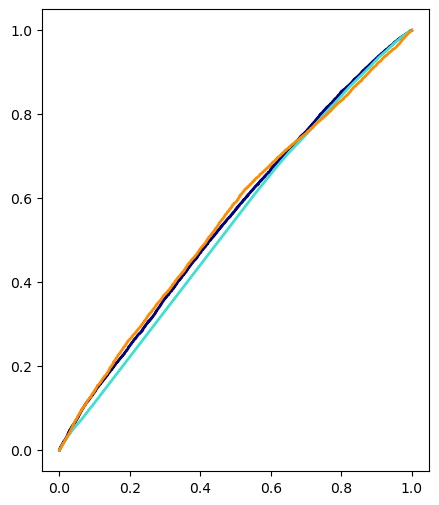

In [80]:
plt.show()

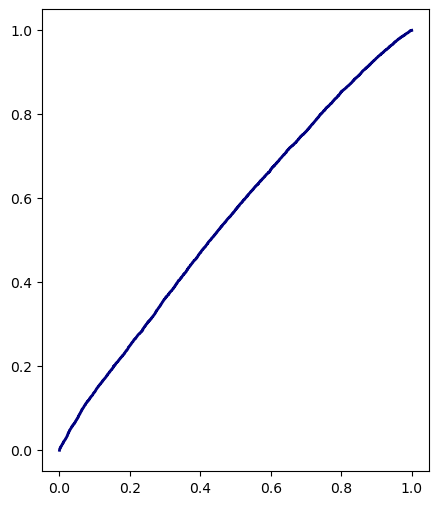

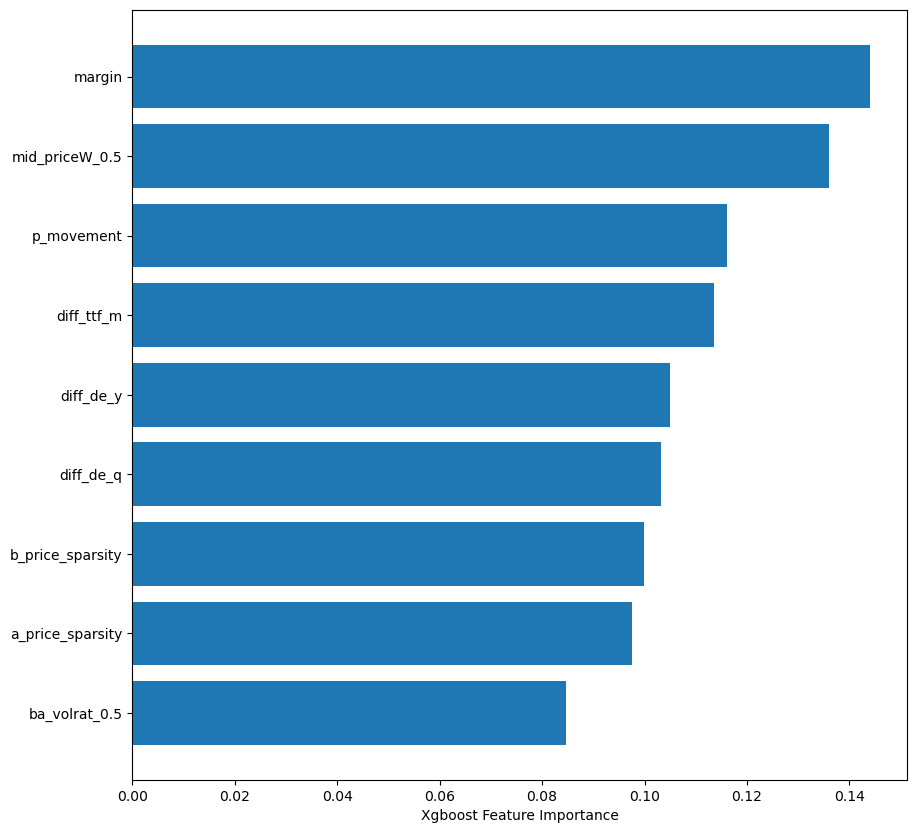

In [69]:
sorted_idx = xgb_model.feature_importances_.argsort()
order_ = []
for i in sorted_idx:
  order_.append(xgb_model.feature_names_in_[i])
plt.figure(figsize=(10, 10))
fig = plt.barh(order_, xgb_model.feature_importances_[sorted_idx])
plt.xlabel("Xgboost Feature Importance")
plt.show()

In [81]:
xgb_model.feature_importances_

array([0.14410722, 0.11606694, 0.09981915, 0.09747698, 0.08475542,
       0.13596122, 0.10318954, 0.10504945, 0.11357407], dtype=float32)

**Confusion matrix**

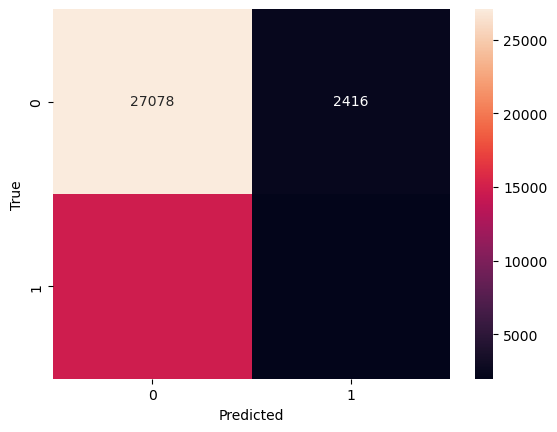

Precision long: 0.45078426915208003
Recall long: 0.11858629350556153
Score ratio: 0.09518348623853211


In [82]:
threshold = 0.48
preds = [(lambda x: 1 if x > threshold else 0)(x[1]) for x in preds_]

cm = confusion_matrix(test['y'], preds)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
false_negatives = cm[1, 0]

precision = true_positives / (true_positives + false_positives)
print("Precision long:", precision)

recall = true_positives / (true_positives + false_negatives)
print("Recall long:", recall)
skore_ratio = (cm[1, 1] + cm[0, 1]) / (cm[1, 1] + cm[0, 1] + cm[1, 0] + cm[0, 0])
print("Score ratio:", skore_ratio)

**Shap values**

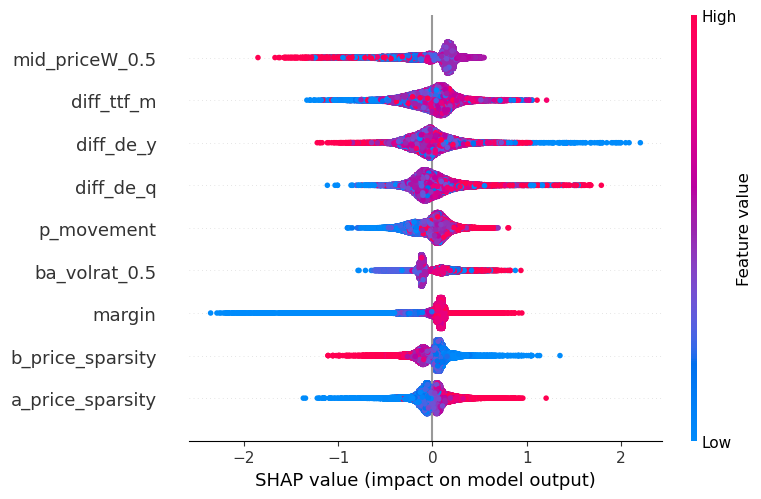

In [83]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(train[feature_cols])
shap.summary_plot(shap_values, train[feature_cols])

### **Precision curve**

In [18]:
preds_p = xgb_model.predict_proba(test[feature_cols])
# threshold for more certainty in predicted values
thold_list = np.arange(0.3, 0.6, 0.001)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    cm = confusion_matrix(test['y'], preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

### No balance data

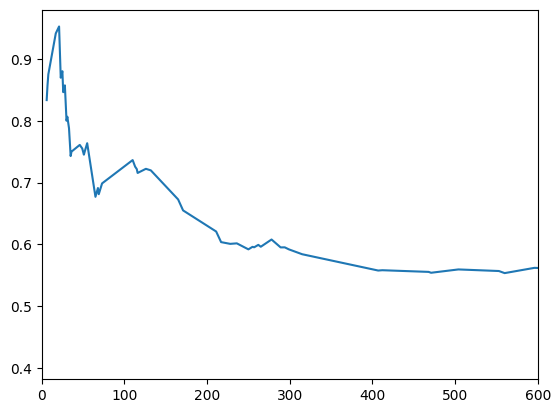

In [222]:
ax = plt.plot(prec_recall_df['count'], prec_recall_df['precision'])
plt.xlim(right=600)  # Set the right limit of the x-axis to 1000
plt.xlim(left=0) # Set the right limit of the x-axis to 1000
plt.show()

In [225]:
prec_recall_df[(prec_recall_df['count'] < 200) & (prec_recall_df['count'] > 50)]

,thold,precision,recall,count
145,0.445,0.654971,0.006698,171
146,0.446,0.672727,0.006638,165
147,0.447,0.719697,0.005681,132
148,0.448,0.722222,0.005442,126
149,0.449,0.715517,0.004964,116
150,0.450,0.721739,0.004964,115
151,0.451,0.725664,0.004904,113
152,0.452,0.736364,0.004844,110
153,0.453,0.698630,0.003050,73
154,0.454,0.681159,0.002811,69


### Train curve

In [226]:
preds_p = xgb_model.predict_proba(train[feature_cols])
# threshold for more certainty in predicted values
thold_list = np.arange(0.1, 0.9, 0.01)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    cm = confusion_matrix(train['y'], preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_24168\3563944166.py:13: 

In [228]:
prec_recall_df[(prec_recall_df['count'] < 200) & (prec_recall_df['count'] > 50)]

,thold,precision,recall,count
35,0.45,0.753846,0.010984,195
36,0.46,0.756522,0.006501,115
37,0.47,0.754717,0.005978,106
38,0.48,0.743590,0.004334,78
39,0.49,0.726027,0.003960,73
40,0.50,0.769231,0.003736,65
41,0.51,0.769231,0.003736,65
42,0.52,0.827586,0.003587,58


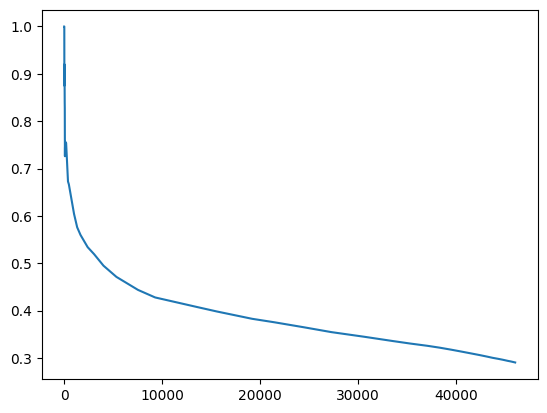

In [227]:
ax = plt.plot(prec_recall_df['count'], prec_recall_df['precision'])

plt.show()

# Model combination

In [251]:
xgb_model_long = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_long.fit(train[feature_cols],
              train['y'].apply(l_long_relabel), eval_metric='logloss')
preds_long = xgb_model_long.predict_proba(test[feature_cols])

xgb_model_short = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_short.fit(train[feature_cols],
              train['y'].apply(l_short_relabel), eval_metric='logloss')
preds_short = xgb_model_short.predict_proba(test[feature_cols])

xgb_model_neu = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_neu.fit(train[feature_cols],
              train['y'].apply(l_neu_relabel), eval_metric='logloss')
preds_neu = xgb_model_neu.predict_proba(test[feature_cols])

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.



In [292]:
print('sdfsf')

In [277]:
preds_comb = [(lambda p: [x/sum(p) for x in p])(p) for p in np.stack((preds_short[:,1], preds_neu[:,1], preds_long[:,1]), axis=1)]
l_relabel_comb = 2 if x > 0.5 else 0 if x < -0.5 else 1
thold_list = np.arange(0.3, 0.6, 0.001)
thold_list = [0]
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
#     preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    preds = [pd.Series(x).idxmax() for x in preds_comb]
    cm = confusion_matrix(test['y'], preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

ValueError: Input y_true contains NaN.

# Model trades data

In [ ]:
dataset_df = pickle.load(open("Z:\Algo_data\dataset_m_margin01.pkl", 'rb'))

In [ ]:
sns.regplot(df_train, x='bids_sparsity', y='y')

In [ ]:
df_train[df_train['bids_sparsity'] > 2]

## Trade side analysis

market reaction after side disbalance

In [ ]:
day = df_train[df_train.index.date == pd.to_datetime("2023-08-01").date()]

In [ ]:
df_train['v_side'] = df_train['trd_vol']

In [ ]:
sides_dict = {
    'date': [],
    'sell': [],
    'buy': [],
    'price_diff': [],
    'v_sell': [],
    'v_buy': [],
    
}
for d in pd.Series(df_train.index.date).unique():
    day_df = df_train[df_train.index.date == d]
    sides_dict['date'].append(d)
    sides_dict['sell'].append(day_df['trd_side'].value_counts()[0])
    sides_dict['buy'].append(day_df['trd_side'].value_counts()[1])
    sides_dict['v_sell'].append(day_df[day_df['trd_side'] < 0.5]['trd_vol'].sum())
    sides_dict['v_buy'].append(day_df[day_df['trd_side'] > 0.5]['trd_vol'].sum())
    sides_dict['price_diff'].append(day_df.iloc[-1]['mid_price'] - day_df.iloc[0]['mid_price'])

In [ ]:
sides_df = pd.DataFrame(sides_dict)

In [ ]:
import plotly.express as px

In [ ]:
import plotly.graph_objects as go

# Assuming sides_df is your DataFrame

# Create the figure
fig = go.Figure()

# Add bars for buy trades
fig.add_trace(go.Bar(
    x=sides_df.index.tolist(),
    y=sides_df['v_buy'],
    name='Buy',
    marker_color='blue',
    opacity=0.6,
    offset=0,  # Set the offset to 0 for buy trades
))

# Add bars for sell trades
fig.add_trace(go.Bar(
    x=sides_df.index.tolist(),
    y=sides_df['v_sell'],
    name='Sell',
    marker_color='red',
    opacity=0.6,
    offset=-0.2,  # Set a slight offset to overlap with buy bars
))

# Add line trace for price_diff column
fig.add_trace(go.Scatter(
    x=sides_df.index.tolist(),
    y=sides_df['price_diff'],
    mode='lines',
    name='Price Difference',
    line=dict(color='green', width=2),
    yaxis='y2'  # Plot the line trace on a secondary y-axis
))

# Update layout
fig.update_layout(
    barmode='overlay',
    yaxis=dict(title='Volume'),
    yaxis2=dict(title='Price Difference', overlaying='y', side='right')  # Secondary y-axis for the line trace
)


# Show the plot
fig.show()
